In [1]:
print("Day-2")

Day-2


In [2]:
# Generators

In [3]:
import pandas as pd
import numpy as np

np.random.seed(10)

data = {
    "User_ID": range(1, 21),
    "Age": np.random.randint(18, 60, 20),
    "Salary": np.random.randint(30000, 120000, 20),
    "Experience": np.random.randint(0, 15, 20)
}

df = pd.DataFrame(data)
df


,User_ID,Age,Salary,Experience
0,1,27,55550,13
1,2,54,109537,6
2,3,33,111587,7
3,4,18,106854,14
4,5,46,58749,8
5,6,43,111349,11
6,7,47,42301,12
7,8,47,36899,10
8,9,26,112329,8
9,10,27,80558,9


In [4]:
def generate_id():
    for x in df["User_ID"]:
        yield x

In [10]:
id = generate_id()

In [11]:
next(id)

1

In [12]:
next(id)

2

In [13]:
next(id)

3

In [21]:
def generate_salary():
    for x,y in zip(df["Salary"], df["Experience"]):
        if y >= 10:
            yield x

In [22]:
salary = generate_salary()

In [23]:
next(salary)

55550

In [24]:
next(salary)

106854

In [25]:
next(salary)

111349

In [26]:
next(salary)

42301

In [37]:
def normalize_salary():
    for x in df["Salary"]:
        yield x, x/max(df["Salary"])

In [38]:
n_salary = normalize_salary()

In [39]:
next(n_salary)

(55550, 0.49345757863786166)

In [40]:
next(n_salary)

(109537, 0.9730308333259308)

In [41]:
next(n_salary)

(111587, 0.991241239018237)

In [42]:
len(df)

20

In [43]:
def generate_data_batch(df, batch_size):
    start = 0
    while start <= len(df):
        batch = df.iloc[start : start+batch_size]
        yield batch
        start = start + batch_size

In [44]:
generate_in_five = generate_data_batch(df, 5)

In [45]:
next(generate_in_five)

,User_ID,Age,Salary,Experience
0,1,27,55550,13
1,2,54,109537,6
2,3,33,111587,7
3,4,18,106854,14
4,5,46,58749,8


In [46]:
next(generate_in_five)

,User_ID,Age,Salary,Experience
5,6,43,111349,11
6,7,47,42301,12
7,8,47,36899,10
8,9,26,112329,8
9,10,27,80558,9


In [62]:
def generator_inc():
    for x,y in zip(df["Salary"], df["Experience"]):
        sal = lambda x,y : x+x*0.1 if y>=10 else x
        yield sal(x,y)

In [63]:
inc = generator_inc()

In [64]:
next(inc)

61105.0

In [65]:
next(inc)

109537

In [66]:
next(inc)

111587

In [67]:
next(inc)

117539.4

In [68]:
# Decorators – Logging & Timing for ML Debugging

In [98]:
def my_decorator(func):
    def wrapper(*args, **kwargs):
        print("Before function")
        func(*args, **kwargs)
        print("After function")
    return wrapper


In [99]:
@my_decorator
def print_name(name):
    print(f"My name is {name}")

In [100]:
print_name("wahaj")

Before function
My name is wahaj
After function


In [106]:
def log_decorator(func):
    def wrapper(*args, **kwargs):       # Accept any args
        print(f"Function {func.__name__} started")
        result = func(*args, **kwargs)  # Call original function
        print(f"Function {func.__name__} ended")
        return result                    # Return the original function's output
    return wrapper


In [107]:
@log_decorator
def greet(name):
    print(f"Hello {name}!")

greet("Wahaj")


Function greet started
Hello Wahaj!
Function greet ended


In [109]:
import time

def timing_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"Function '{func.__name__}' took {end_time - start_time:.4f} seconds")
        return result
    return wrapper


In [128]:
@timing_decorator
def slow_function():
    total = 0
    for i in range(100000):
        total += i
    return total

slow_function()


Function 'slow_function' took 0.0176 seconds


4999950000

In [129]:
@log_decorator
@timing_decorator
def process_data(n):
    total = sum(range(n))
    return total

process_data(1_000_000)


Function wrapper started
Function 'process_data' took 0.0218 seconds
Function wrapper ended


499999500000

In [82]:
import pandas as pd
import numpy as np

np.random.seed(7)

data = {
    "Feature1": np.random.randn(1000),
    "Feature2": np.random.randn(1000),
    "Target": np.random.randint(0, 2, 1000)
}

df = pd.DataFrame(data)
df.head()


,Feature1,Feature2,Target
0,1.690526,0.884888,0
1,-0.465937,-0.909118,1
2,0.032820,1.135317,1
3,0.407516,0.086851,0
4,-0.788923,0.751667,0


In [130]:
def my_log_decorator(func):
    def wrapper():
        print(f"Function {func.__name__} started")
        func()
        print(f"Function {func.__name__} ended")
    return wrapper

In [131]:
@my_log_decorator
def load_data():
    print("Loading dataset")

In [132]:
load_data()

Function load_data started
Loading dataset
Function load_data ended


In [143]:
def my_time_decorator(func):
    def wrapper():
        start = time.time()
        result = func()
        end = time.time()
        print(f"Function '{func.__name__}' took {end - start:.4f} seconds")
        return result
    return wrapper

In [144]:
@my_time_decorator
def cal_mean_f1():
    sum = 0
    for x in df["Feature1"]:
        sum+=x
    return x/len(df)

In [145]:
cal_mean_f1()

Function 'cal_mean_f1' took 0.0003 seconds


-0.0006774392378782009

In [146]:
# Type Hints

In [148]:
from typing import List, Union

In [151]:
def perfect_squares(lst: List[int]) -> List[int]:
    return [x**2 for x in lst]

In [152]:
perfect_squares([1,3,5,7,9])

[1, 9, 25, 49, 81]

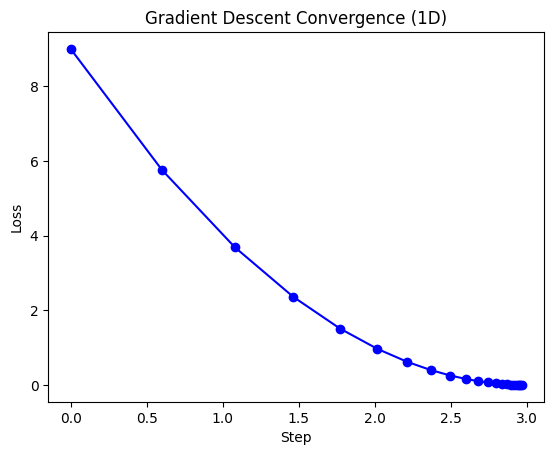

In [153]:
import numpy as np
import matplotlib.pyplot as plt

# Example: f(w) = (w-3)^2 (minimum at w=3)
def f(w):
    return (w - 3)**2

def df(w):
    return 2 * (w - 3)

w = 0  # starting point
learning_rate = 0.1
steps = [w]

for _ in range(20):
    w = w - learning_rate * df(w)
    steps.append(w)

# Plot convergence
plt.plot(steps, f(np.array(steps)), 'o-', color='blue')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Gradient Descent Convergence (1D)")
plt.show()
